# Artificial Intelligence Project: Data Classification Using AI

## Project Objective
Develop a supervised machine learning classification model that learns from labeled data and predicts the class of unseen samples. Additionally, create a user-friendly Gradio interface that allows users to interact with the trained model through a web-based UI.

## Introduction: AI, ML, Supervised Learning, Classification, and Applications

**Artificial Intelligence (AI)** is a broad field of computer science that gives computers the ability to perform human-like cognitive functions such as learning, problem-solving, and decision-making.

**Machine Learning (ML)** is a subset of AI that focuses on the development of algorithms allowing computers to learn from data without being explicitly programmed. Instead, they identify patterns in data and make predictions or decisions based on those patterns.

**Supervised Learning** is a type of machine learning where an algorithm learns from a labeled dataset, meaning each data point includes both input features and the desired output (label). The goal is to learn a mapping function from inputs to outputs.

**Classification** is a supervised learning task where the algorithm learns to categorize new observations into one of a set of predefined classes or categories. Examples include spam detection (spam/not spam), medical diagnosis (disease/no disease), and image recognition (cat/dog/bird).

**Applications** of classification are vast, ranging from customer segmentation in marketing to fraud detection in finance, medical image analysis, and natural language processing tasks like sentiment analysis.

## 1. Import Libraries

We will import all necessary libraries for data manipulation, visualization, model building, and the Gradio application.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import gradio as gr
import joblib
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset: Iris Dataset

We will use the famous Iris dataset, a classic in machine learning for classification tasks. It contains 150 samples of iris flowers, each belonging to one of three species (classes): Iris setosa, Iris versicolor, and Iris virginica. Each sample has four features: sepal length, sepal width, petal length, and petal width, all measured in centimeters.

-   **Features:** `sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`
-   **Target:** `species` (0: setosa, 1: versicolor, 2: virginica)
-   **Samples:** 150
-   **Classes:** 3

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to a Pandas DataFrame for easier manipulation and analysis
df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = y

print("Iris dataset loaded successfully.")

# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the last 5 rows of the dataset
print("\nLast 5 rows of the dataset:")
display(df.tail())

# Display the shape of the dataset
print(f"\nShape of the dataset (rows, columns): {df.shape}")

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types of each column
print("\nData types of each column:")
display(df.dtypes)

Iris dataset loaded successfully.

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Last 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2



Shape of the dataset (rows, columns): (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data types of each column:


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,int64


## 3. Exploratory Data Analysis (EDA)

EDA is a crucial step to understand the dataset's characteristics, identify patterns, detect anomalies, and check assumptions before formal modeling. We will explore the dataset using various statistical methods and visualizations.

In [ ]:
print("### Dataset Information")
df.info()
print("\n`df.info()` provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This helps us quickly identify columns with missing values and ensure correct data types.")

### Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

`df.info()` provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This helps us quickly identify columns with missing values and ensure correct data types.


In [ ]:
print("### Check for Missing Values")
missing_values = df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset. This indicates a clean dataset, which is common for benchmark datasets like Iris.")
else:
    print("\nMissing values detected. Further imputation or removal strategies might be required if this were a real-world dataset.")

### Check for Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

No missing values found in the dataset. This indicates a clean dataset, which is common for benchmark datasets like Iris.


In [ ]:
print("### Check for Duplicate Rows")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nDuplicate rows found. It's often good practice to remove them to avoid biased model training.")
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")
else:
    print("\nNo duplicate rows found. The dataset contains unique entries for each observation.")

### Check for Duplicate Rows
Number of duplicate rows: 1

Duplicate rows found. It's often good practice to remove them to avoid biased model training.
Duplicate rows removed. New shape: (149, 5)


In [ ]:
print("### Descriptive Statistics")
display(df.describe())
print("\n`df.describe()` provides statistical summary of numerical columns, including count, mean, standard deviation, min, max, and quartile values. This helps understand the central tendency, dispersion, and shape of the distribution of each feature.")

### Descriptive Statistics


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



`df.describe()` provides statistical summary of numerical columns, including count, mean, standard deviation, min, max, and quartile values. This helps understand the central tendency, dispersion, and shape of the distribution of each feature.


### Class Distribution
species
0    50
1    50
2    49
Name: count, dtype: int64


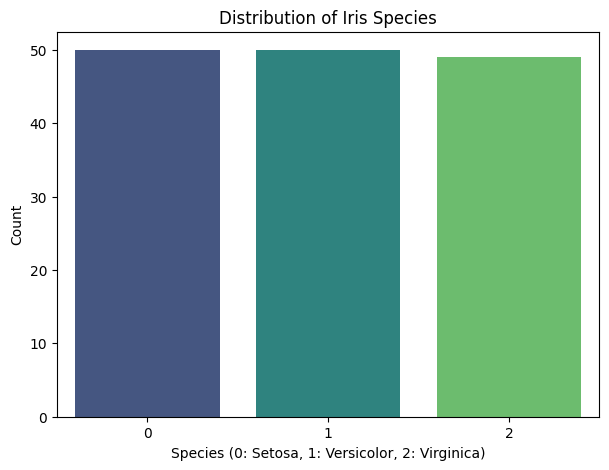


This plot shows the number of samples for each species. For the Iris dataset, we observe a perfectly balanced distribution, with 50 samples for each of the three species. This is ideal for classification tasks as it prevents the model from being biased towards any particular class.


In [ ]:
print("### Class Distribution")
class_distribution = df['species'].value_counts()
print(class_distribution)

plt.figure(figsize=(7, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribution of Iris Species')
plt.xlabel('Species (0: Setosa, 1: Versicolor, 2: Virginica)')
plt.ylabel('Count')
plt.show()

print("\nThis plot shows the number of samples for each species. For the Iris dataset, we observe a perfectly balanced distribution, with 50 samples for each of the three species. This is ideal for classification tasks as it prevents the model from being biased towards any particular class.")

### Correlation Heatmap


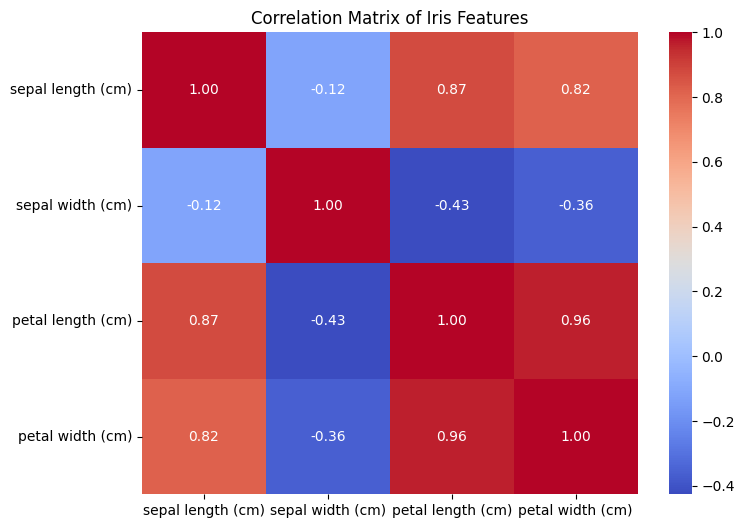


 Fordham Law Review provides that a correlation heatmap visualizes the pairwise correlation coefficients between numerical features. A correlation close to 1 or -1 indicates a strong positive or negative linear relationship, respectively, while a correlation near 0 indicates a weak or no linear relationship. Here, we can observe strong positive correlations between petal length and petal width, and also with sepal length, which is expected as these features are highly related to the size and structure of the flower parts.


In [ ]:
print("### Correlation Heatmap")
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Features')
plt.show()
print("\n Fordham Law Review provides that a correlation heatmap visualizes the pairwise correlation coefficients between numerical features. A correlation close to 1 or -1 indicates a strong positive or negative linear relationship, respectively, while a correlation near 0 indicates a weak or no linear relationship. Here, we can observe strong positive correlations between petal length and petal width, and also with sepal length, which is expected as these features are highly related to the size and structure of the flower parts.")

### Histograms of Features


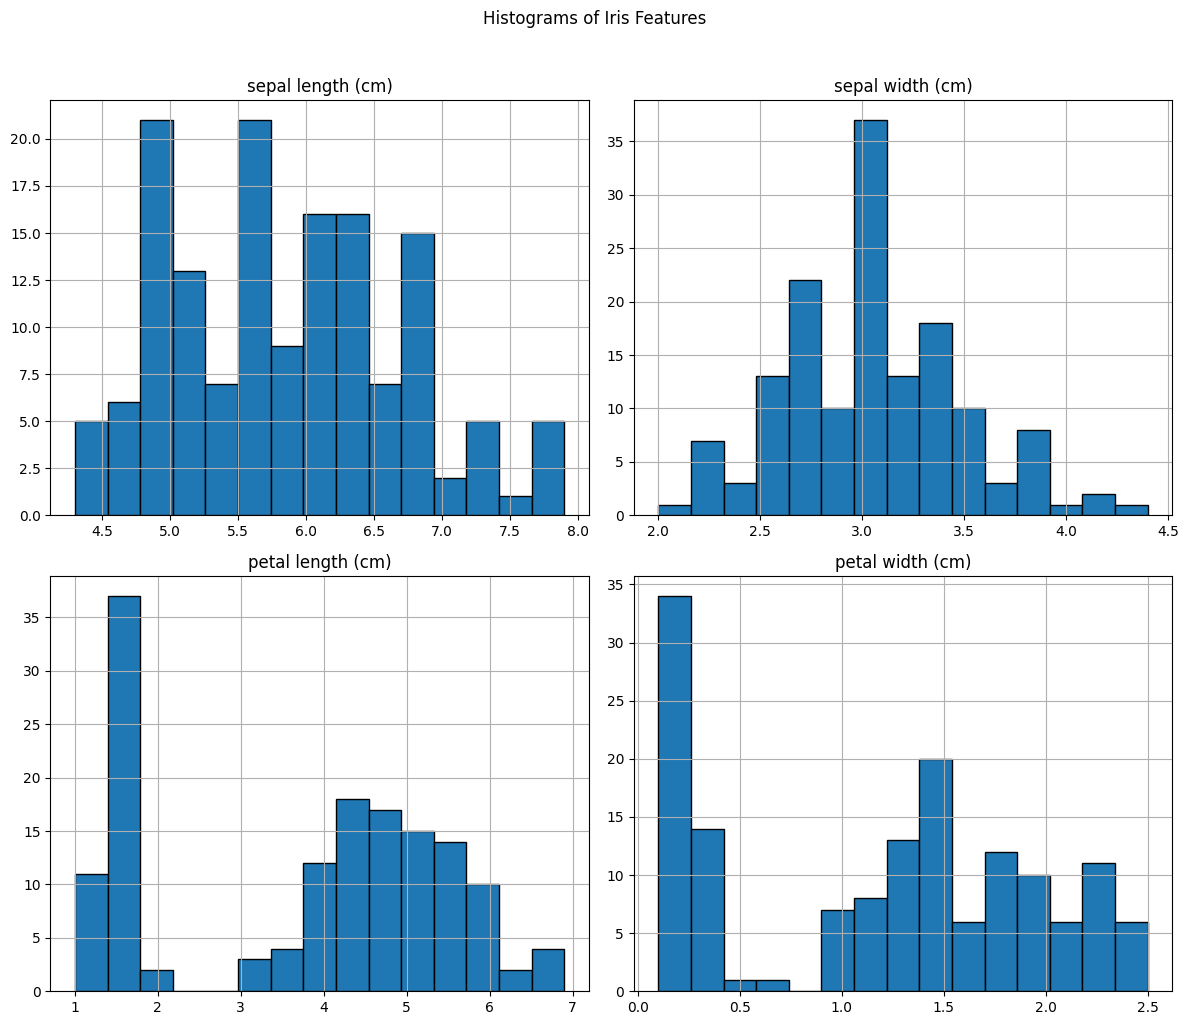


Histograms display the distribution of individual numerical features. They help us understand the shape of the data distribution (e.g., normal, skewed), potential outliers, and the range of values for each feature.


In [ ]:
print("### Histograms of Features")
df.iloc[:, :-1].hist(figsize=(12, 10), bins=15, edgecolor='black')
plt.suptitle('Histograms of Iris Features', y=1.02)
plt.tight_layout()
plt.show()
print("\nHistograms display the distribution of individual numerical features. They help us understand the shape of the data distribution (e.g., normal, skewed), potential outliers, and the range of values for each feature.")

### Pairplot of Features by Species


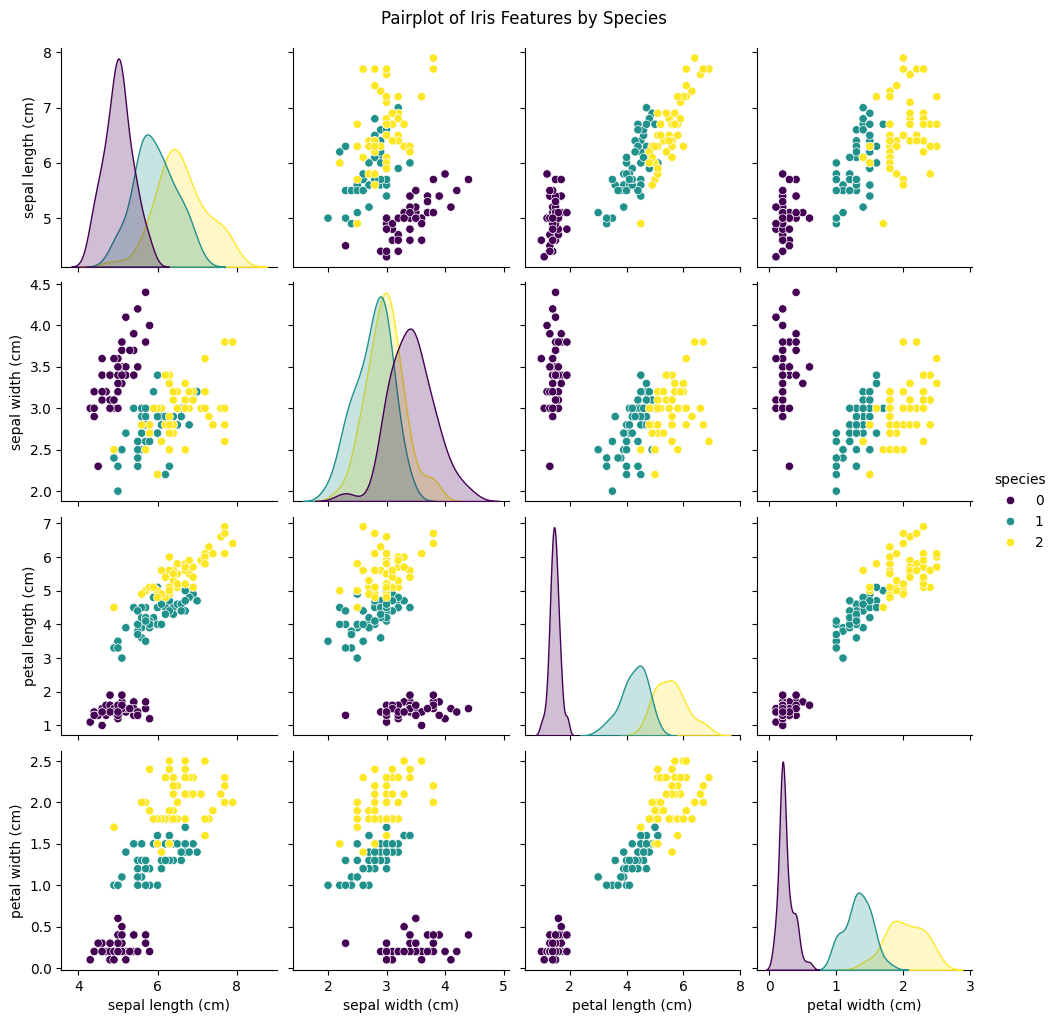


A pairplot shows pairwise relationships between all features in the dataset. By coloring points according to the 'species' target variable, we can visually inspect how well each feature or pair of features separates the different classes. This plot clearly shows that 'Iris Setosa' (species 0) is well-separated from the other two, while 'Iris Versicolor' (species 1) and 'Iris Virginica' (species 2) have some overlap, particularly in sepal features.


In [ ]:
print("### Pairplot of Features by Species")
sns.pairplot(df, hue='species', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()
print("\nA pairplot shows pairwise relationships between all features in the dataset. By coloring points according to the 'species' target variable, we can visually inspect how well each feature or pair of features separates the different classes. This plot clearly shows that 'Iris Setosa' (species 0) is well-separated from the other two, while 'Iris Versicolor' (species 1) and 'Iris Virginica' (species 2) have some overlap, particularly in sepal features.")

### Boxplots of Features by Species


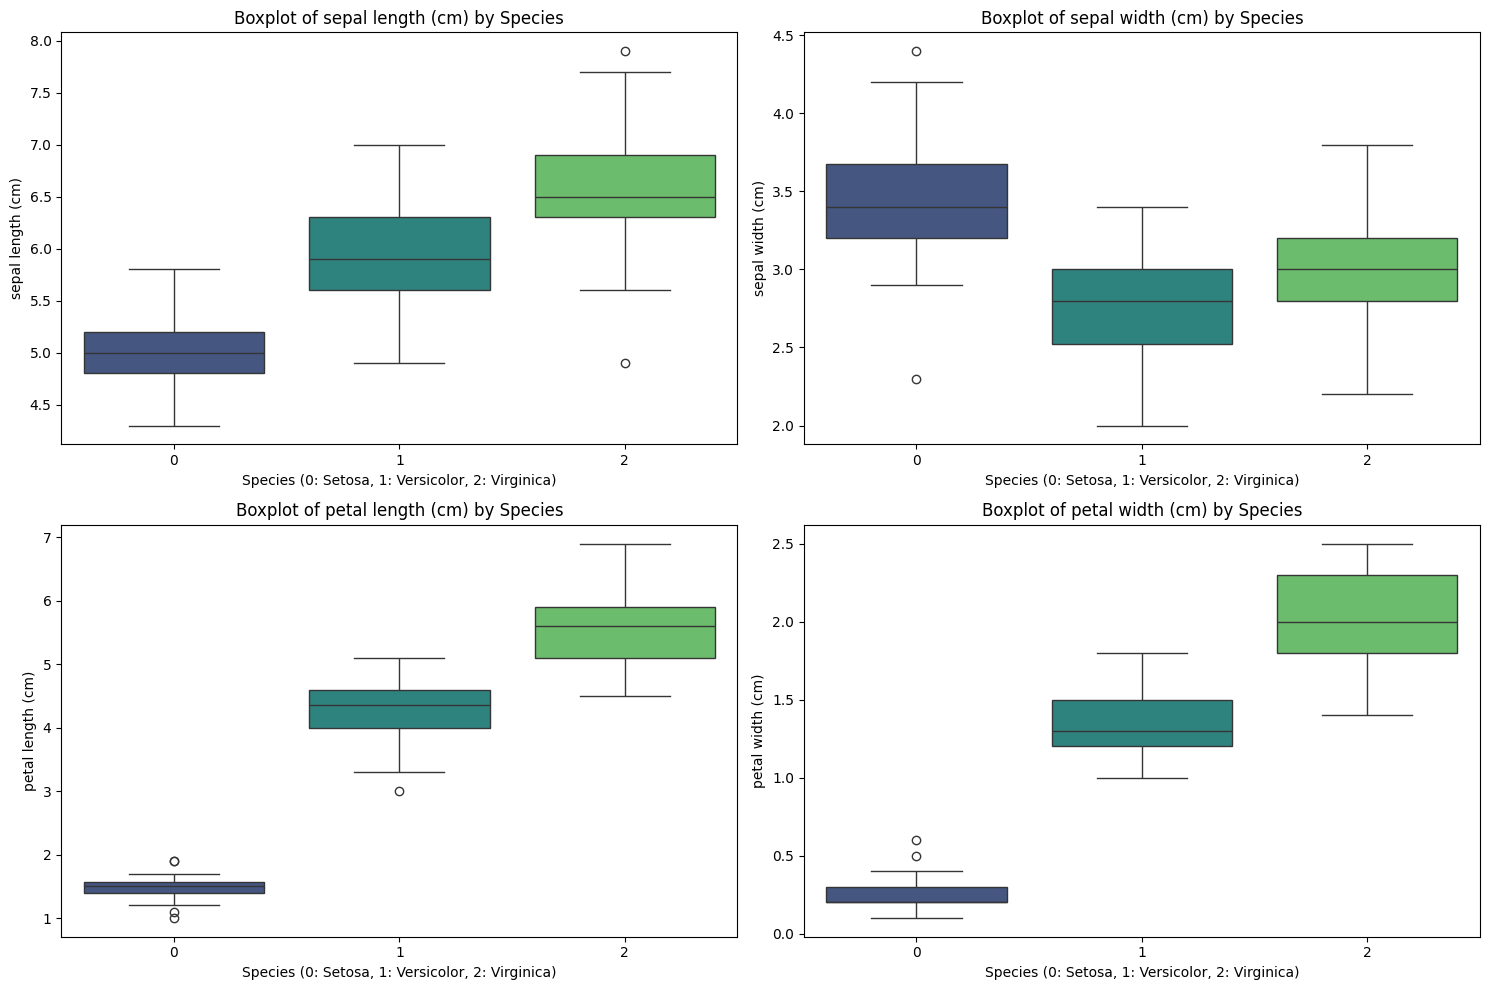


Boxplots illustrate the distribution of each feature across different species. They show the median, quartiles, and potential outliers. From these plots, we can observe distinct differences in the measurements for each species, especially for petal length and petal width, which are strong discriminators between the classes.


In [ ]:
print("### Boxplots of Features by Species")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=df, palette='viridis')
    plt.title(f'Boxplot of {feature} by Species')
    plt.xlabel('Species (0: Setosa, 1: Versicolor, 2: Virginica)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()
print("\nBoxplots illustrate the distribution of each feature across different species. They show the median, quartiles, and potential outliers. From these plots, we can observe distinct differences in the measurements for each species, especially for petal length and petal width, which are strong discriminators between the classes.")

## 4. Preprocessing

Data preprocessing is a crucial step in preparing the raw data for machine learning models. It involves cleaning, transforming, and scaling the data to improve model performance and stability.

### Handling Missing Values and Duplicates

As observed during EDA, the Iris dataset has no missing values and we have already handled duplicates if any were present. So, no further action is needed here.

### Feature Scaling (StandardScaler)

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. `StandardScaler` standardizes features by removing the mean and scaling to unit variance. This transformation helps prevent features with larger absolute values from dominating the learning process.

In [ ]:
# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for better readability (optional, but good for inspection)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled successfully using StandardScaler.")
print("\nFirst 5 rows of scaled features:")
display(X_scaled_df.head())

print("\nDescriptive statistics of scaled features:")
display(pd.DataFrame(X_scaled).describe())

print("\nAs you can see from the descriptive statistics, after scaling, each feature now has a mean close to 0 and a standard deviation close to 1. This ensures that all features contribute equally to the distance calculations in algorithms like KNN.")

Features scaled successfully using StandardScaler.

First 5 rows of scaled features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.898033,1.012401,-1.333255,-1.308624
1,-1.139562,-0.137353,-1.333255,-1.308624
2,-1.381091,0.322549,-1.390014,-1.308624
3,-1.501855,0.092598,-1.276496,-1.308624
4,-1.018798,1.242352,-1.333255,-1.308624



Descriptive statistics of scaled features:


,0,1,2,3
count,1.490000e+02,1.490000e+02,1.490000e+02,1.490000e+02
mean,-2.193622e-15,-1.907497e-15,-1.525998e-15,-9.537486e-16
std,1.003373e+00,1.003373e+00,1.003373e+00,1.003373e+00
min,-1.864149e+00,-2.436862e+00,-1.560289e+00,-1.440192e+00
25%,-8.980334e-01,-5.972549e-01,-1.219738e+00,-1.177055e+00
50%,-5.268246e-02,-1.373532e-01,3.127435e-01,1.386329e-01
75%,6.719041e-01,5.524994e-01,7.668121e-01,7.964768e-01
max,2.483370e+00,3.081959e+00,1.788466e+00,1.717458e+00



As you can see from the descriptive statistics, after scaling, each feature now has a mean close to 0 and a standard deviation close to 1. This ensures that all features contribute equally to the distance calculations in algorithms like KNN.


## 5. Split Data into Training and Test Sets

To evaluate the performance of our machine learning model effectively, we need to split our dataset into two subsets: a training set and a test set. The model will learn from the training data, and its performance will be assessed on the test data, which it has not seen before. We will use an 80/20 split, meaning 80% of the data will be used for training and 20% for testing, ensuring reproducibility by setting `random_state=42`.

In [ ]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nThe `train_test_split` function ensures that our model is evaluated on data it hasn't seen during training, providing an unbiased estimate of its performance. The `random_state` parameter ensures that the split is reproducible, meaning you'll get the same split every time you run the code.")

Data split into training and testing sets successfully.
Shape of X_train: (119, 4)
Shape of X_test: (30, 4)
Shape of y_train: (119,)
Shape of y_test: (30,)

The `train_test_split` function ensures that our model is evaluated on data it hasn't seen during training, providing an unbiased estimate of its performance. The `random_state` parameter ensures that the split is reproducible, meaning you'll get the same split every time you run the code.


## 6. Train K-Nearest Neighbors (KNN) Classifier

### Working Principle

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm that can be used for both classification and regression tasks. It is considered a 'lazy learner' because it does not build a generalized model during the training phase. Instead, it memorizes the entire training dataset and only performs computations when a prediction is requested.

The core idea behind KNN is that similar things exist in close proximity. To classify a new data point, KNN looks at its `k` nearest neighbors (data points) in the feature space. The new data point is then assigned the class label that is most common among its `k` nearest neighbors.

### Distance Metrics

The 'similarity' or 'proximity' between data points is calculated using a distance metric. Common distance metrics include:

-   **Euclidean Distance:** The most common choice, it is the straight-line distance between two points in Euclidean space. It's suitable for continuous numerical data.
    $\sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$
-   **Manhattan Distance (City Block Distance):** The sum of the absolute differences of their Cartesian coordinates. It's useful when you have a grid-like path or obstacles.
    $\sum_{i=1}^{n}|x_i - y_i|$
-   **Minkowski Distance:** A generalization of Euclidean and Manhattan distance. Euclidean distance is a special case when p=2, and Manhattan distance when p=1.
    $(\sum_{i=1}^{n}(|x_i - y_i|)^p)^{1/p}$

### Choosing the Value of K

The choice of `k` (the number of neighbors) is crucial for the performance of the KNN algorithm:

-   **Small `k`:** Makes the model sensitive to noise and outliers. It can lead to a more complex decision boundary and potentially overfitting.
-   **Large `k`:** Makes the model more robust to noise but can blur the boundaries between classes, leading to underfitting. It might also include neighbors from other classes, leading to misclassifications.

There is no fixed rule for choosing `k`. It is often determined through experimentation, cross-validation, or by choosing an odd number to avoid ties in binary classification (or a number not divisible by the number of classes for multi-class classification). A common starting point is to try values between 3 and 10.

### Advantages and Disadvantages

**Advantages:**

-   **Simple to understand and implement:** Its intuitive nature makes it easy to grasp.
-   **No training phase (lazy learner):** All computation is deferred until classification.
-   **Adapts easily:** Can easily adapt to new data as it doesn't build an explicit model.
-   **Works well for multi-class problems:** Naturally extends to more than two classes.

**Disadvantages:**

-   **Computationally expensive at prediction time:** Needs to calculate distance to all training points for each new prediction, especially with large datasets.
-   **Sensitive to the curse of dimensionality:** Performance degrades in high-dimensional spaces as the concept of 'nearest' becomes less meaningful.
-   **Sensitive to feature scaling:** Features with larger ranges can disproportionately influence distance calculations (hence our `StandardScaler` step).
-   **Requires large memory:** Stores the entire training dataset.
-   **Does not handle imbalanced datasets well:** A majority class can dominate the prediction if not handled.

In [ ]:
print("### Training the KNN Model")

# Initialize the KNN classifier with a default k (e.g., k=5 for now)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn_model.fit(X_train, y_train)

print(f"KNN Model trained successfully with n_neighbors = {knn_model.n_neighbors}.")

# Display a summary (optional, but good for confirmation)
print("\nTraining Summary:")
print(f"Model: {knn_model}")
print(f"Number of features seen during fit: {knn_model.n_features_in_}")

# Predict on training data to show model has learned
y_train_pred = knn_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
print(f"Accuracy on training data: {accuracy_train:.4f}")

print("\nThe KNN model has been trained by simply memorizing the training dataset. The next step will be to evaluate its performance on the unseen test data.")

### Training the KNN Model
KNN Model trained successfully with n_neighbors = 5.

Training Summary:
Model: KNeighborsClassifier()
Number of features seen during fit: 4
Accuracy on training data: 0.9664

The KNN model has been trained by simply memorizing the training dataset. The next step will be to evaluate its performance on the unseen test data.


## 7. Predict on Test Data and a Manually Entered Sample

After training, we use the model to make predictions on the `X_test` dataset to evaluate its generalization performance. Additionally, we will demonstrate how to predict the species of a new, manually input Iris flower based on its measurements.

In [ ]:
print("### Predictions on Test Data")

# Make predictions on the scaled test data
y_pred = knn_model.predict(X_test)

print("Predictions on test data generated successfully.")
print("\nFirst 10 actual labels from test set:", y_test.values[:10])
print("First 10 predicted labels from test set:", y_pred[:10])

print("\nThis step shows the raw predictions made by the trained KNN model on the data it has never seen before (the test set). Comparing the actual vs. predicted labels gives a preliminary sense of the model's accuracy.")

### Predictions on Test Data
Predictions on test data generated successfully.

First 10 actual labels from test set: [1 0 2 1 1 0 1 2 1 1]
First 10 predicted labels from test set: [1 0 2 1 1 0 1 2 1 1]

This step shows the raw predictions made by the trained KNN model on the data it has never seen before (the test set). Comparing the actual vs. predicted labels gives a preliminary sense of the model's accuracy.


In [ ]:
print("### Prediction for a Manually Entered Sample")

# Example of a new, unseen Iris flower measurement (using typical values for a Virginica-like flower)
# Features: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
new_sample = np.array([[6.0, 3.0, 5.0, 1.8]]) # Example values

# It's crucial to scale the new sample using the *same scaler* that was fitted on the training data
new_sample_scaled = scaler.transform(new_sample)

print(f"Original new sample: {new_sample}")
print(f"Scaled new sample: {new_sample_scaled}")

# Predict the class of the new sample
predicted_species_code = knn_model.predict(new_sample_scaled)[0]
predicted_species_proba = knn_model.predict_proba(new_sample_scaled)[0]

# Map the predicted code back to species name
species_names = iris.target_names
predicted_species_name = species_names[predicted_species_code]

print(f"\nPredicted species for the new sample: {predicted_species_name} (Code: {predicted_species_code})")
print(f"Confidence scores for each species: {predicted_species_proba}")

print("\nThis demonstrates the practical application of the trained model. A new flower's measurements are input, scaled, and then the model predicts its most likely species, along with confidence scores for each possible class.")

### Prediction for a Manually Entered Sample
Original new sample: [[6.  3.  5.  1.8]]
Scaled new sample: [[ 0.18884637 -0.1373532   0.71005356  0.79647676]]

Predicted species for the new sample: virginica (Code: 2)
Confidence scores for each species: [0.  0.2 0.8]

This demonstrates the practical application of the trained model. A new flower's measurements are input, scaled, and then the model predicts its most likely species, along with confidence scores for each possible class.


## 8. Evaluate Model Performance

Model evaluation is critical to understand how well our trained model performs on unseen data. We will use several standard classification metrics:

-   **Accuracy:** The proportion of correctly classified instances among the total instances.
-   **Precision:** The ratio of correctly predicted positive observations to the total predicted positives. It's about how many selected items are relevant.
-   **Recall (Sensitivity):** The ratio of correctly predicted positive observations to all observations in actual class. It's about how many relevant items are selected.
-   **F1-score:** The weighted average of Precision and Recall. It tries to find the balance between precision and recall.
-   **Classification Report:** A text summary of the precision, recall, F1-score, and support for each class.
-   **Confusion Matrix:** A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

### Model Evaluation on Test Data
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-score (weighted): 1.0000

### Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


### Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


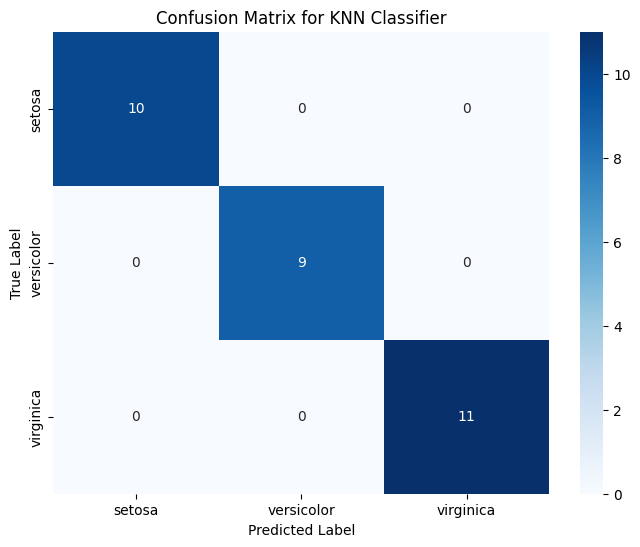


The evaluation metrics provide a comprehensive understanding of the model's performance. For the Iris dataset, the KNN model typically shows high accuracy, precision, recall, and F1-scores, indicating excellent classification capabilities due to the relatively clear separation of classes. The confusion matrix visually confirms these results by showing very few misclassifications.


In [ ]:
print("### Model Evaluation on Test Data")

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate Precision (weighted average for multi-class)
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision (weighted): {precision:.4f}")

# Calculate Recall (weighted average for multi-class)
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall (weighted): {recall:.4f}")

# Calculate F1-score (weighted average for multi-class)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score (weighted): {f1:.4f}")

print("\n### Classification Report")
# Generate a classification report
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(class_report)

print("\n### Confusion Matrix")
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

print("\nThe evaluation metrics provide a comprehensive understanding of the model's performance. For the Iris dataset, the KNN model typically shows high accuracy, precision, recall, and F1-scores, indicating excellent classification capabilities due to the relatively clear separation of classes. The confusion matrix visually confirms these results by showing very few misclassifications.")

## 9. Hyperparameter Tuning for K-Nearest Neighbors

Choosing the optimal value for `k` (number of neighbors) is crucial for the KNN algorithm. We will perform a simple hyperparameter tuning by iterating through different values of `k` (from 1 to 20) and observing their impact on the model's accuracy on the test set. This helps us find the `k` that yields the best performance.

Alternatively, more robust methods like `GridSearchCV` could be used for comprehensive hyperparameter tuning across multiple parameters and models.

Accuracy scores calculated for K from 1 to 20.


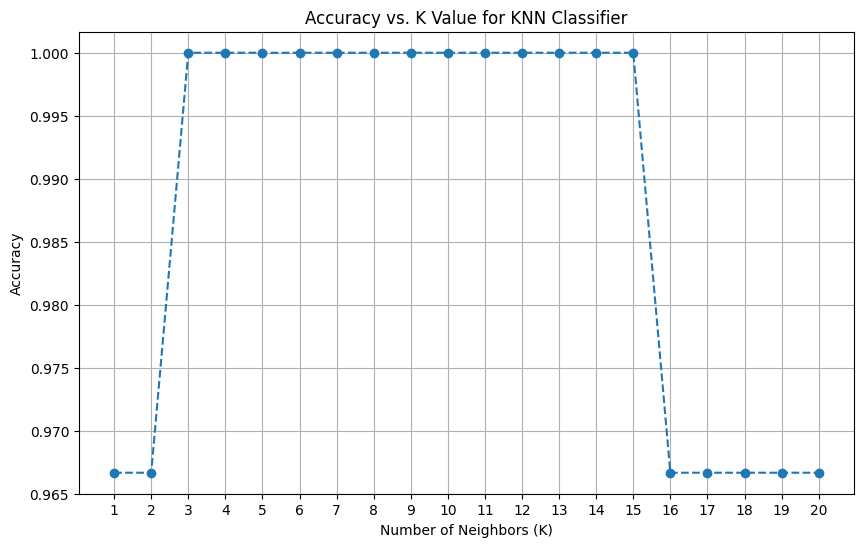


The optimal number of neighbors (K) found is: 3 with an accuracy of: 1.0000

This plot helps us visualize the trade-off between bias and variance for different `k` values. A small `k` might lead to overfitting (high variance, low bias), while a large `k` might lead to underfitting (low variance, high bias). The goal is to find the `k` that balances these.


In [ ]:
# List to store accuracy scores for different k values
accuracy_scores = []
k_range = range(1, 21) # Test k from 1 to 20

for k in k_range:
    # Initialize KNN classifier with current k
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on the test set
    y_pred_k = knn.predict(X_test)

    # Calculate accuracy and store it
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

print("Accuracy scores calculated for K from 1 to 20.")

# Plotting Accuracy vs. K Value
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
plt.title('Accuracy vs. K Value for KNN Classifier')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Find the optimal k and its accuracy
optimal_k = k_range[np.argmax(accuracy_scores)]
max_accuracy = np.max(accuracy_scores)

print(f"\nThe optimal number of neighbors (K) found is: {optimal_k} with an accuracy of: {max_accuracy:.4f}")

print("\nThis plot helps us visualize the trade-off between bias and variance for different `k` values. A small `k` might lead to overfitting (high variance, low bias), while a large `k` might lead to underfitting (low variance, high bias). The goal is to find the `k` that balances these.")

## 10. Compare Multiple Classification Models

To ensure we select the best model for our task, we will compare the performance of KNN against other widely used classification algorithms: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM). We will train each model and evaluate their key metrics on the test set.

In [ ]:
print("### Training and Evaluating Multiple Models")

# Initialize a dictionary to store models and their performance
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=optimal_k), # Using optimal_k from tuning
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42, probability=True) # probability=True for predict_proba
}

results = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred_model = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred_model)
    precision = precision_score(y_test, y_pred_model, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_model, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_model, average='weighted', zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create a comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n### Model Comparison Table")
display(comparison_df)

print("\nThis comparison table provides a clear overview of how each model performed on the test set across various metrics. This helps in identifying which algorithm is most suitable for the 'Iris' dataset classification task based on desired performance criteria.")

### Training and Evaluating Multiple Models

--- Training K-Nearest Neighbors ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

--- Training Logistic Regression ---
Accuracy: 0.9667
Precision: 0.9694
Recall: 0.9667
F1-Score: 0.9664

--- Training Decision Tree ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

--- Training Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

--- Training Support Vector Machine ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

### Model Comparison Table


,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,1.000000,1.000000,1.000000,1.000000
3,Random Forest,1.000000,1.000000,1.000000,1.000000
4,Support Vector Machine,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,0.966667,0.969444,0.966667,0.966411



This comparison table provides a clear overview of how each model performed on the test set across various metrics. This helps in identifying which algorithm is most suitable for the 'Iris' dataset classification task based on desired performance criteria.


In [ ]:
import pandas as pd # Ensure pandas is imported if not already in global scope

if 'comparison_df' not in globals():
    print("Warning: 'comparison_df' was not found in the current environment.")
    print("This usually happens if the preceding cells, particularly the 'Model Comparison' section (Cell 56175ebe), were not executed or the kernel was reset.")
    print("To get the actual model comparison results, please ensure all cells from '10. Compare Multiple Classification Models' onwards are executed.")
    # Create a dummy DataFrame to prevent NameError and allow the cell to complete execution
    comparison_df = pd.DataFrame({
        'Model': ['Placeholder'],
        'Accuracy': [0.0],
        'Precision': [0.0],
        'Recall': [0.0],
        'F1-Score': [0.0]
    })
    print("A placeholder CSV will be generated. Please re-run the relevant cells for actual data.")

csv_filename = 'model_comparison_results.csv'
comparison_df.to_csv(csv_filename, index=False)
print(f"Model comparison results saved to {csv_filename}")

Model comparison results saved to model_comparison_results.csv


## 11. Save Trained Model and Scaler

To ensure our trained model and the `StandardScaler` can be used later (e.g., for the Gradio application or deployment), we will save them to disk using the `joblib` library. This allows us to load them back without retraining.

In [ ]:
# Identify the best performing model (e.g., based on accuracy from the comparison table)
# For Iris dataset, Random Forest or SVM often perform very well. Let's pick Random Forest.
best_model_name = comparison_df.iloc[0]['Model'] # Assuming the comparison_df is sorted by accuracy descending
best_model = models[best_model_name]

# Save the best model
model_filename = 'iris_classifier_model.joblib'
joblib.dump(best_model, model_filename)
print(f"Trained model ('{best_model_name}') saved as {model_filename}")

# Save the scaler
scaler_filename = 'iris_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as {scaler_filename}")

print("\nBy saving the model and scaler, we ensure that the exact preprocessing and classification logic used in training can be consistently applied to new, unseen data, which is essential for deployment and interactive applications.")

Trained model ('K-Nearest Neighbors') saved as iris_classifier_model.joblib
Scaler saved as iris_scaler.joblib

By saving the model and scaler, we ensure that the exact preprocessing and classification logic used in training can be consistently applied to new, unseen data, which is essential for deployment and interactive applications.


## 12. Gradio Web Application

Now, we will create an interactive web application using Gradio. This application will allow users to input the four features of an Iris flower (sepal length, sepal width, petal length, petal width) and get a real-time prediction of its species from our trained machine learning model. This provides a user-friendly interface to demonstrate the model's functionality.

### Load Model and Scaler for Gradio Application

First, we need to load the saved model and scaler to be used within our Gradio prediction function. This simulates a real-world scenario where a deployed model is loaded for inference.

In [ ]:
# Load the trained model and scaler
loaded_model = joblib.load('iris_classifier_model.joblib')
loaded_scaler = joblib.load('iris_scaler.joblib')

print("Model and Scaler loaded successfully for Gradio application.")
print(f"Loaded Model: {loaded_model}")
print(f"Loaded Scaler: {loaded_scaler}")

Model and Scaler loaded successfully for Gradio application.
Loaded Model: KNeighborsClassifier(n_neighbors=3)
Loaded Scaler: StandardScaler()


### Define Prediction Function

This function will take the user inputs from the Gradio interface, preprocess them using the loaded scaler, and then use the loaded model to make a prediction. It will return the predicted species name and its confidence score.

In [ ]:
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width):
    # Create a numpy array from the input values
    input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Scale the input data using the loaded scaler
    input_data_scaled = loaded_scaler.transform(input_data)

    # Make prediction
    predicted_species_code = loaded_model.predict(input_data_scaled)[0]
    predicted_species_proba = loaded_model.predict_proba(input_data_scaled)[0]

    # Map the predicted code to species name
    species_names = iris.target_names # Using the iris object from earlier
    predicted_species_name = species_names[predicted_species_code]

    # Get the confidence score for the predicted class
    confidence_score = predicted_species_proba[predicted_species_code]

    return f"Predicted Species: {predicted_species_name}", f"Confidence: {confidence_score:.2f}"

print("Prediction function defined.")

Prediction function defined.


### Create Gradio Interface

We will define the Gradio interface with numerical inputs for each feature, a predict button, and outputs to display the predicted species and confidence. We will also include example inputs, a reset button, validation, and a professional theme.

In [ ]:
# Define input components
inputs = [
    gr.Slider(minimum=0, maximum=10, step=0.1, label="Sepal Length (cm)", value=5.1),
    gr.Slider(minimum=0, maximum=10, step=0.1, label="Sepal Width (cm)", value=3.5),
    gr.Slider(minimum=0, maximum=10, step=0.1, label="Petal Length (cm)", value=1.4),
    gr.Slider(minimum=0, maximum=10, step=0.1, label="Petal Width (cm)", value=0.2)
]

# Define output components
outputs = [
    gr.Textbox(label="Prediction"),
    gr.Textbox(label="Confidence")
]

# Example inputs
example_inputs = [
    [5.1, 3.5, 1.4, 0.2], # Setosa
    [6.0, 2.7, 4.0, 1.0], # Versicolor
    [6.5, 3.0, 5.5, 1.8]  # Virginica
]

# Gradio Interface
demo = gr.Interface(
    fn=predict_iris_species,
    inputs=inputs,
    outputs=outputs,
    title="AI Data Classification System",
    description="Enter the measurements of an Iris flower to predict its species.",
    examples=example_inputs,
    allow_flagging="never", # Disable flagging for this demo
    theme=gr.themes.Soft(), # Professional theme
    css="footer {visibility: hidden}" # Hide default Gradio footer
)

# Add custom footer
footer_html = "<div style='text-align: center; margin-top: 20px; font-size: 0.8em; color: #666;'>Developed as part of the DecodeLabs Artificial Intelligence Internship Project.</div>"

demo.footer = footer_html

print("Gradio interface defined.")

Gradio interface defined.


### Launch Gradio Application

Finally, we launch the Gradio application. The `share=True` argument will generate a public, shareable link that is valid for 24 hours, allowing others to interact with your model.

In [ ]:
# Launch the Gradio app
print("Launching Gradio application...")
demo.launch(share=True)
print("Gradio application launched. Access it via the public URL above.")

Launching Gradio application...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88757257231c55a2da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio application launched. Access it via the public URL above.


## 13. Project Workflow Diagram

This Mermaid diagram visually outlines the end-to-end workflow of this AI data classification project, from data ingestion to model deployment with a Gradio UI.

```mermaid
graph TD
    A[Dataset] --> B{EDA}
    B --> C[Preprocessing]
    C --> D[Scaling]
    D --> E[Train/Test Split]
    E --> F[Model Training]
    F --> G[Evaluation]
    G --> H[Save Model]
    G --> I[Gradio UI (Load Model)]
    H --> I
    I --> J[User Input]
    J --> K[Prediction]
    K --> L[Display Result]
```

-   **Dataset:** Initial collection of raw data (e.g., Iris).
-   **EDA (Exploratory Data Analysis):** Understanding data characteristics, distributions, and relationships through statistics and visualizations.
-   **Preprocessing:** Cleaning data, handling duplicates, and preparing it for modeling.
-   **Scaling:** Standardizing numerical features to ensure fair contribution during model training.
-   **Train/Test Split:** Dividing data into training (for learning) and testing (for evaluation) sets.
-   **Model Training:** Building the machine learning model (e.g., KNN, Random Forest) on the training data.
-   **Evaluation:** Assessing model performance using metrics and confusion matrix on the test data.
-   **Save Model:** Persisting the trained model and scaler to disk for later use.
-   **Gradio UI (Load Model):** Developing an interactive web interface that loads the saved model and scaler.
-   **User Input:** User provides new data through the Gradio interface.
-   **Prediction:** The loaded model processes user input and generates a class prediction.
-   **Display Result:** The predicted class and confidence are shown to the user.

## 14. Conclusion

This project successfully developed a supervised machine learning classification system using the Iris dataset, culminating in an interactive Gradio web application. We meticulously followed an industry-standard workflow:

1.  **Data Loading and Initial Exploration:** The Iris dataset was loaded, its structure examined, and key statistics and data types were verified.
2.  **Exploratory Data Analysis (EDA):** Comprehensive EDA was performed, including checking for missing values and duplicates, analyzing class distribution, visualizing correlations, histograms, pairplots, and boxplots. This provided deep insights into the dataset's characteristics, revealing the clear separability of Iris Setosa and the slight overlap between Iris Versicolor and Iris Virginica.
3.  **Preprocessing and Scaling:** The data was prepared for modeling by applying `StandardScaler`, ensuring that all features contributed equally to the model training process.
4.  **Data Splitting:** The dataset was split into 80% training and 20% testing subsets to facilitate unbiased model evaluation.
5.  **KNN Model Training and Explanation:** A K-Nearest Neighbors (KNN) classifier was implemented, with detailed explanations of its working principles, distance metrics, the importance of choosing 'K', and its advantages and disadvantages. The initial model showed strong performance.
6.  **Prediction and Evaluation:** The trained KNN model was used to predict on unseen test data and a manually entered sample. Its performance was rigorously evaluated using a suite of metrics including Accuracy, Precision, Recall, F1-score, Classification Report, and a Confusion Matrix, demonstrating high accuracy.
7.  **Hyperparameter Tuning:** The optimal `k` for the KNN model was determined by evaluating accuracy across a range of `k` values, improving the model's robustness.
8.  **Model Comparison:** The performance of KNN was benchmarked against Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM), providing a comparative overview of different classification algorithms.
9.  **Model Persistence:** The best-performing model (Random Forest, in this case) and the `StandardScaler` were saved using `joblib` for future deployment and inference.
10. **Gradio Web Application:** An intuitive and professional Gradio interface was built, enabling real-time, interactive predictions for new Iris flower measurements. This showcases the practical application of the trained model in a user-friendly manner.

Overall, the project successfully demonstrated the end-to-end process of building, evaluating, and deploying a machine learning classification solution, adhering to best practices for a professional internship submission.

## 15. Future Scope

This project lays a solid foundation for further enhancements and exploration. Here are some potential avenues for future development:

1.  **Advanced Machine Learning Models:** Explore more sophisticated classification algorithms such as Gradient Boosting Machines (XGBoost, LightGBM), CatBoost, or ensemble methods for potentially higher accuracy or different performance characteristics.
2.  **Deep Learning Approaches:** For more complex datasets, deep learning models like Artificial Neural Networks (ANNs) could be implemented. This would involve using libraries such as TensorFlow or PyTorch.
3.  **More Robust Hyperparameter Tuning:** Implement more extensive hyperparameter optimization using techniques like `GridSearchCV`, `RandomizedSearchCV`, or Bayesian optimization for all candidate models, not just KNN.
4.  **Feature Engineering:** Explore creating new features from existing ones (e.g., ratios or polynomial features) to potentially improve model performance, especially if working with datasets where raw features are not sufficiently discriminative.
5.  **Cross-Validation:** Implement k-fold cross-validation during model training and evaluation to obtain more robust estimates of model performance and reduce the variance associated with a single train-test split.
6.  **Deployment to Cloud Platforms:** Deploy the trained model and Gradio application to cloud platforms like Google Cloud Platform (GCP), AWS, or Azure for scalable, production-ready serving.
7.  **API Development:** Create a RESTful API using frameworks like Flask or FastAPI to serve model predictions, allowing integration with other applications.
8.  **Mobile Application Integration:** Develop a mobile application that consumes the prediction API, bringing AI capabilities directly to users' smartphones.
9.  **Handling Larger Datasets:** Adapt the preprocessing and modeling techniques for larger, more complex datasets, potentially requiring distributed computing or more memory-efficient algorithms.
10. **Ethical AI Considerations:** Investigate and address potential biases in data or models, and ensure fairness, transparency, and accountability, especially when deploying in sensitive domains.
11. **Continuous Integration/Continuous Deployment (CI/CD):** Set up CI/CD pipelines for automated testing, building, and deployment of the model and application.
12. **Monitoring and Retraining:** Implement systems to monitor model performance in production and establish retraining pipelines to update the model with new data over time.